# Chapter 3 — Waves
**Elementary Fluid Dynamics · Acheson (1990)**

Colab visualization notebook · SeoulTech PSE Lab

---
**Contents**
1. Deep Water Waves — Dispersion, Particle Orbits & Energy (§3.2)
2. General Dispersion Relation — $\omega^2 = gk\tanh(kh)$ (§3.3, 3.5)
3. Group Velocity — Wave Packet Evolution (§3.4)
4. Capillary-Gravity Waves — Phase Speed Minimum (§3.4)
5. Sound Waves & Mach Cone — Speed of Sound, Supersonic Flow (§3.6–3.7)
6. Internal Gravity Waves — Brunt-Väisälä Frequency, $\omega=N\sin\theta$ (§3.8)
7. Nonlinear Shallow Water — Wave Steepening & Hydraulic Jump (§3.9–3.10)
8. KdV Soliton — $\eta=a\,\mathrm{sech}^2[\kappa(x-ct)]$ (§3.11)
9. Physics Validation Checks


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({
    'figure.facecolor':'#1e1e2e','axes.facecolor':'#27273d',
    'axes.edgecolor':'#313244','axes.labelcolor':'#cdd6f4',
    'xtick.color':'#6c7086','ytick.color':'#6c7086',
    'text.color':'#cdd6f4','grid.color':'#313244','grid.linewidth':0.5,
    'lines.linewidth':2.0,'font.size':11,'axes.titlesize':12,
    'axes.titleweight':'bold','figure.dpi':120,
})
TEAL='#4ec9b0'; ORANGE='#ce9178'; BLUE='#9cdcfe'; PURPLE='#c792ea'
GREEN='#a6e3a1'; MUTED='#6c7086'; FG='#cdd6f4'; BG='#1e1e2e'; PINK='#f38ba8'
g = 9.81
print("Setup complete.")

Setup complete.


## 1 · Deep Water Waves

For deep-water surface gravity waves, $\omega^2 = gk$, giving:
- Phase speed: $c = \sqrt{g/k}$ — longer waves travel faster (dispersive)
- Particle orbits: circles of radius $ae^{kz}$, decaying with depth
- Energy: $E = \frac{1}{2}\rho g a^2$ (equally split kinetic/potential)

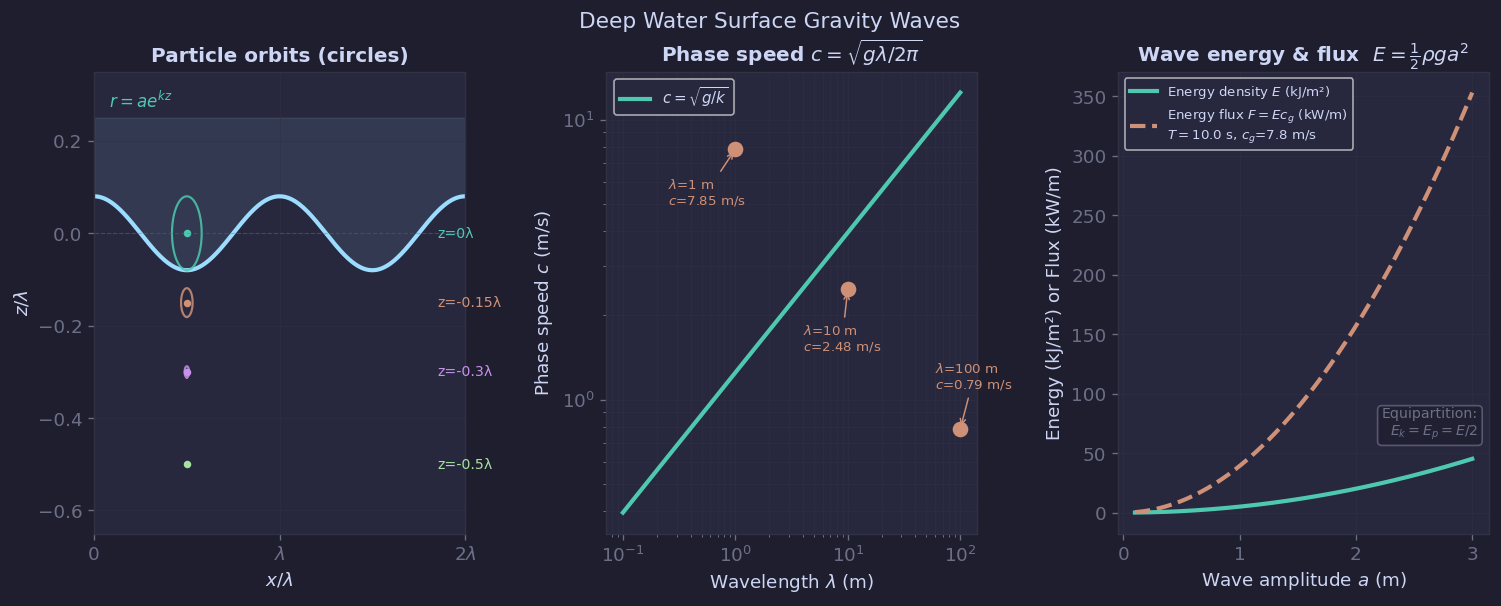

Figure 3.1: Deep water waves saved


In [2]:
fig = plt.figure(figsize=(15, 5))
fig.suptitle("Deep Water Surface Gravity Waves", color=FG, fontsize=13)
gs = gridspec.GridSpec(1, 3, figure=fig, wspace=0.38)

# (a) Particle orbits
ax = fig.add_subplot(gs[0])
lam=1.0; k=2*np.pi/lam; a=0.08; omega=np.sqrt(g*k)
x = np.linspace(0, 2*lam, 300)
eta = a*np.cos(k*x)
ax.fill_between(x, eta, 0.25, color=BLUE, alpha=0.10)
ax.plot(x, eta, color=BLUE, lw=2.5)
depths=[0,-0.15,-0.30,-0.50]; cols_d=[TEAL,ORANGE,PURPLE,GREEN]
for z0,col in zip(depths,cols_d):
    r=a*np.exp(k*z0); th=np.linspace(0,2*np.pi,80)
    ax.plot(0.5*lam+r*np.sin(th), z0-r*np.cos(th), color=col, lw=1.3, alpha=0.85)
    ax.plot(0.5*lam, z0, 'o', color=col, ms=3.5)
    ax.text(1.85*lam, z0, f'z={z0}λ', color=col, fontsize=8.5, va='center')
ax.axhline(0, color=MUTED, lw=0.7, ls='--', alpha=0.4)
ax.set_xlim(0,2*lam); ax.set_ylim(-0.65,0.35)
ax.set_xlabel('$x/\\lambda$'); ax.set_ylabel('$z/\\lambda$')
ax.set_title('Particle orbits (circles)')
ax.set_xticks([0,lam,2*lam]); ax.set_xticklabels(['0','$\\lambda$','$2\\lambda$'])
ax.text(0.04,0.96,r'$r=ae^{kz}$',transform=ax.transAxes,color=TEAL,fontsize=10,va='top')
ax.grid(True,lw=0.3)

# (b) Phase speed vs wavelength
ax2 = fig.add_subplot(gs[1])
lam_arr=np.logspace(-1,2,300); k_arr=2*np.pi/lam_arr; c_arr=np.sqrt(g/k_arr)
ax2.loglog(lam_arr, c_arr, color=TEAL, lw=2.5, label=r'$c=\sqrt{g/k}$')
for lam_ex,xt,yt in [(1.0,0.25,5.0),(10.0,4.0,1.5),(100.0,60.0,1.1)]:
    c_ex=np.sqrt(g*2*np.pi/lam_ex)
    ax2.scatter([lam_ex],[c_ex],s=70,color=ORANGE,zorder=5)
    ax2.annotate(f'$\\lambda$={lam_ex:.0f} m\n$c$={c_ex:.2f} m/s',
                 xy=(lam_ex,c_ex),xytext=(xt,yt),fontsize=8,color=ORANGE,
                 arrowprops=dict(arrowstyle='->',color=ORANGE,lw=0.9))
ax2.set_xlabel('Wavelength $\\lambda$ (m)'); ax2.set_ylabel('Phase speed $c$ (m/s)')
ax2.set_title(r'Phase speed $c=\sqrt{g\lambda/2\pi}$')
ax2.legend(fontsize=9,loc='upper left'); ax2.grid(True,which='both',lw=0.3)

# (c) Energy & flux
ax3 = fig.add_subplot(gs[2])
rho=1025; a_arr=np.linspace(0.1,3.0,200)
E_arr=0.5*rho*g*a_arr**2
T_ex=10.0; lam_ex2=g*T_ex**2/(2*np.pi); c_ex2=np.sqrt(g*lam_ex2/(2*np.pi)); cg_ex2=c_ex2/2
F_arr=E_arr*cg_ex2
ax3.plot(a_arr,E_arr/1000,color=TEAL,lw=2.5,label='Energy density $E$ (kJ/m²)')
ax3.plot(a_arr,F_arr/1000,color=ORANGE,lw=2.5,ls='--',
         label=f'Energy flux $F=Ec_g$ (kW/m)\n$T={T_ex}$ s, $c_g$={cg_ex2:.1f} m/s')
ax3.set_xlabel('Wave amplitude $a$ (m)'); ax3.set_ylabel('Energy (kJ/m²) or Flux (kW/m)')
ax3.set_title(r'Wave energy & flux  $E=\frac{1}{2}\rho g a^2$')
ax3.legend(fontsize=8,loc='upper left'); ax3.grid(True,lw=0.3)
ax3.text(0.97,0.2,'Equipartition:\n$E_k = E_p = E/2$',
         transform=ax3.transAxes,color=MUTED,fontsize=8.5,ha='right',va='bottom',
         bbox=dict(boxstyle='round,pad=0.3',fc='#1e1e2e',ec=MUTED,alpha=0.7))

plt.tight_layout()
plt.savefig('ch03_fig1_deep_water.png', dpi=150, bbox_inches='tight', facecolor=BG)
plt.show()
print("Figure 3.1: Deep water waves saved")

## 2 · General Dispersion Relation

$$\omega^2 = gk\tanh(kh)$$

- Deep water ($kh\gg 1$): $\tanh(kh)\to 1$, dispersive, $c\propto k^{-1/2}$
- Shallow water ($kh\ll 1$): $\tanh(kh)\approx kh$, **non-dispersive**, $c=\sqrt{gh}$

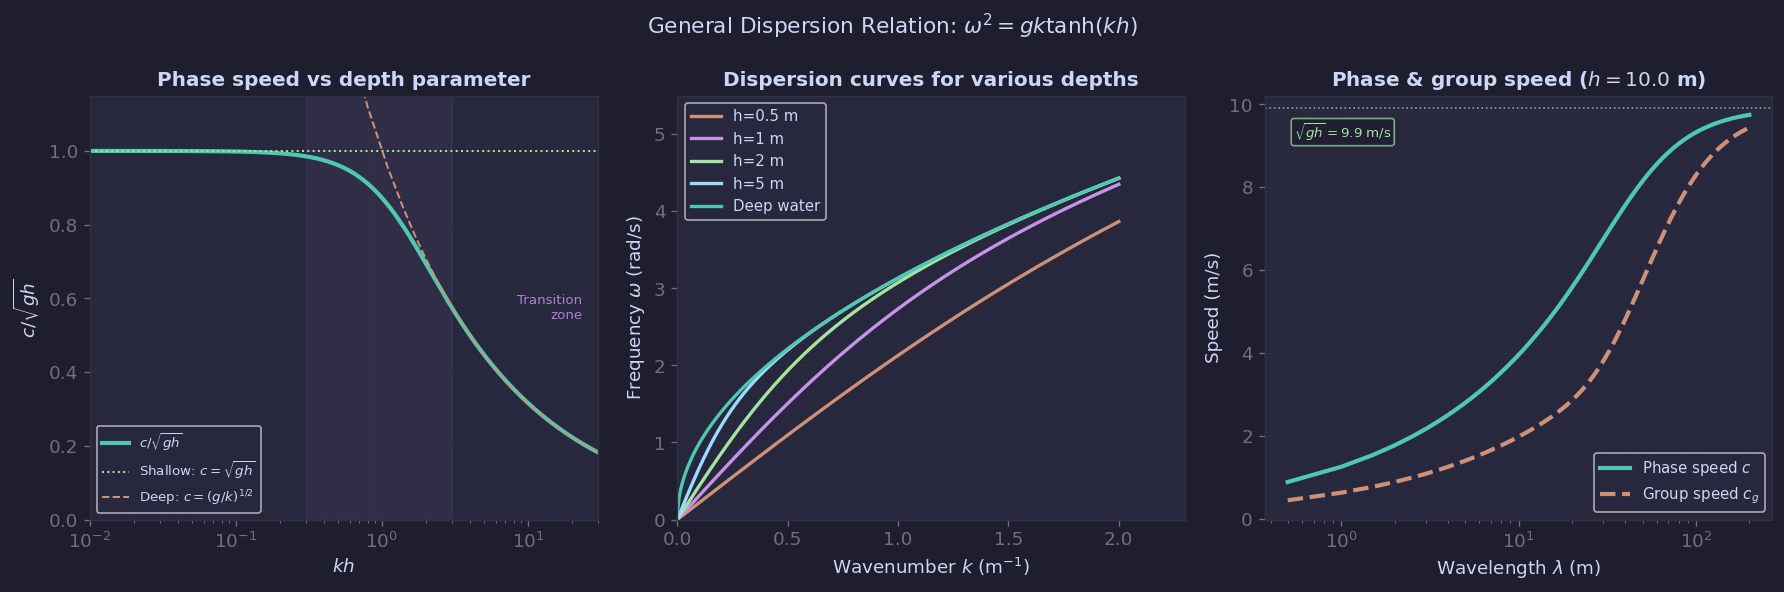

Figure 3.2: Dispersion relation saved


In [3]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle(r"General Dispersion Relation: $\omega^2 = gk\tanh(kh)$", color=FG, fontsize=13)

ax=axes[0]
kh_arr=np.logspace(-2,1.5,400); c_norm=np.sqrt(np.tanh(kh_arr)/kh_arr)
ax.semilogx(kh_arr,c_norm,color=TEAL,lw=2.5,label=r'$c/\sqrt{gh}$')
ax.axhline(1.0,color=GREEN,lw=1.2,ls=':',label=r'Shallow: $c=\sqrt{gh}$')
kh_d=np.linspace(0.5,30,100)
ax.semilogx(kh_d,1/np.sqrt(kh_d),color=ORANGE,lw=1.2,ls='--',label=r'Deep: $c=(g/k)^{1/2}$')
ax.axvspan(0.3,3.0,alpha=0.06,color=PURPLE)
ax.text(0.97,0.5,'Transition\nzone',transform=ax.transAxes,
        color=PURPLE,fontsize=8,ha='right',va='center',alpha=0.85)
ax.set_xlabel('$kh$'); ax.set_ylabel(r'$c/\sqrt{gh}$')
ax.set_title('Phase speed vs depth parameter')
ax.legend(fontsize=8,loc='lower left')
ax.set_xlim(0.01,30); ax.set_ylim(0,1.15); ax.grid(True,which='both',lw=0.3)

ax=axes[1]
k_arr2=np.linspace(0.001,2.0,300)
depths_h=[0.5,1.0,2.0,5.0,np.inf]
cols_h=[ORANGE,PURPLE,GREEN,BLUE,TEAL]
labels_h=['h=0.5 m','h=1 m','h=2 m','h=5 m','Deep water']
for h_v,col,lbl in zip(depths_h,cols_h,labels_h):
    om=np.sqrt(g*k_arr2) if np.isinf(h_v) else np.sqrt(g*k_arr2*np.tanh(k_arr2*h_v))
    ax.plot(k_arr2,om,color=col,lw=2,label=lbl)
ax.legend(fontsize=9,loc='upper left')
ax.set_xlabel('Wavenumber $k$ (m$^{-1}$)'); ax.set_ylabel(r'Frequency $\omega$ (rad/s)')
ax.set_title('Dispersion curves for various depths')
ax.set_xlim(0,2.3); ax.set_ylim(0,5.5); ax.grid(True,lw=0.3)

ax=axes[2]
h_val=10.0; lam_p=np.linspace(0.5,200,400); k_p=2*np.pi/lam_p
kh_p=k_p*h_val; om_p=np.sqrt(g*k_p*np.tanh(kh_p)); c_p=om_p/k_p
cg_p=(g/(2*om_p))*(np.tanh(kh_p)+kh_p/np.cosh(kh_p)**2)
ax.semilogx(lam_p,c_p,color=TEAL,lw=2.5,label='Phase speed $c$')
ax.semilogx(lam_p,cg_p,color=ORANGE,lw=2.5,ls='--',label='Group speed $c_g$')
c_sh=np.sqrt(g*h_val)
ax.axhline(c_sh,color=GREEN,lw=1,ls=':',alpha=0.7)
# 수정: transform 혼용 제거 → axes 좌표계로 통일
ax.text(0.25, 0.9, f'$\\sqrt{{gh}}={c_sh:.1f}$ m/s',
        transform=ax.transAxes, color=GREEN, fontsize=8, ha='right',
        bbox=dict(boxstyle='round,pad=0.2', fc='#1e1e2e', ec=GREEN, alpha=0.7))
ax.set_xlabel('Wavelength $\\lambda$ (m)'); ax.set_ylabel('Speed (m/s)')
ax.set_title(f'Phase & group speed ($h={h_val}$ m)')
ax.legend(fontsize=9,loc='lower right'); ax.grid(True,which='both',lw=0.3)

plt.tight_layout()
plt.savefig('ch03_fig2_dispersion.png', dpi=150, bbox_inches='tight', facecolor=BG)
plt.show()
print("Figure 3.2: Dispersion relation saved")

## 3 · Group Velocity — Wave Packet

A Gaussian wave packet: $\eta = \int A(k)\cos(kx-\omega t)\,dk$
with $A(k)\propto e^{-(k-k_0)^2/(2\Delta k)^2}$.

- Envelope travels at $c_g = d\omega/dk|_{k_0}$
- For deep water: $c_g = c/2$ — phase crests move through and out of packet

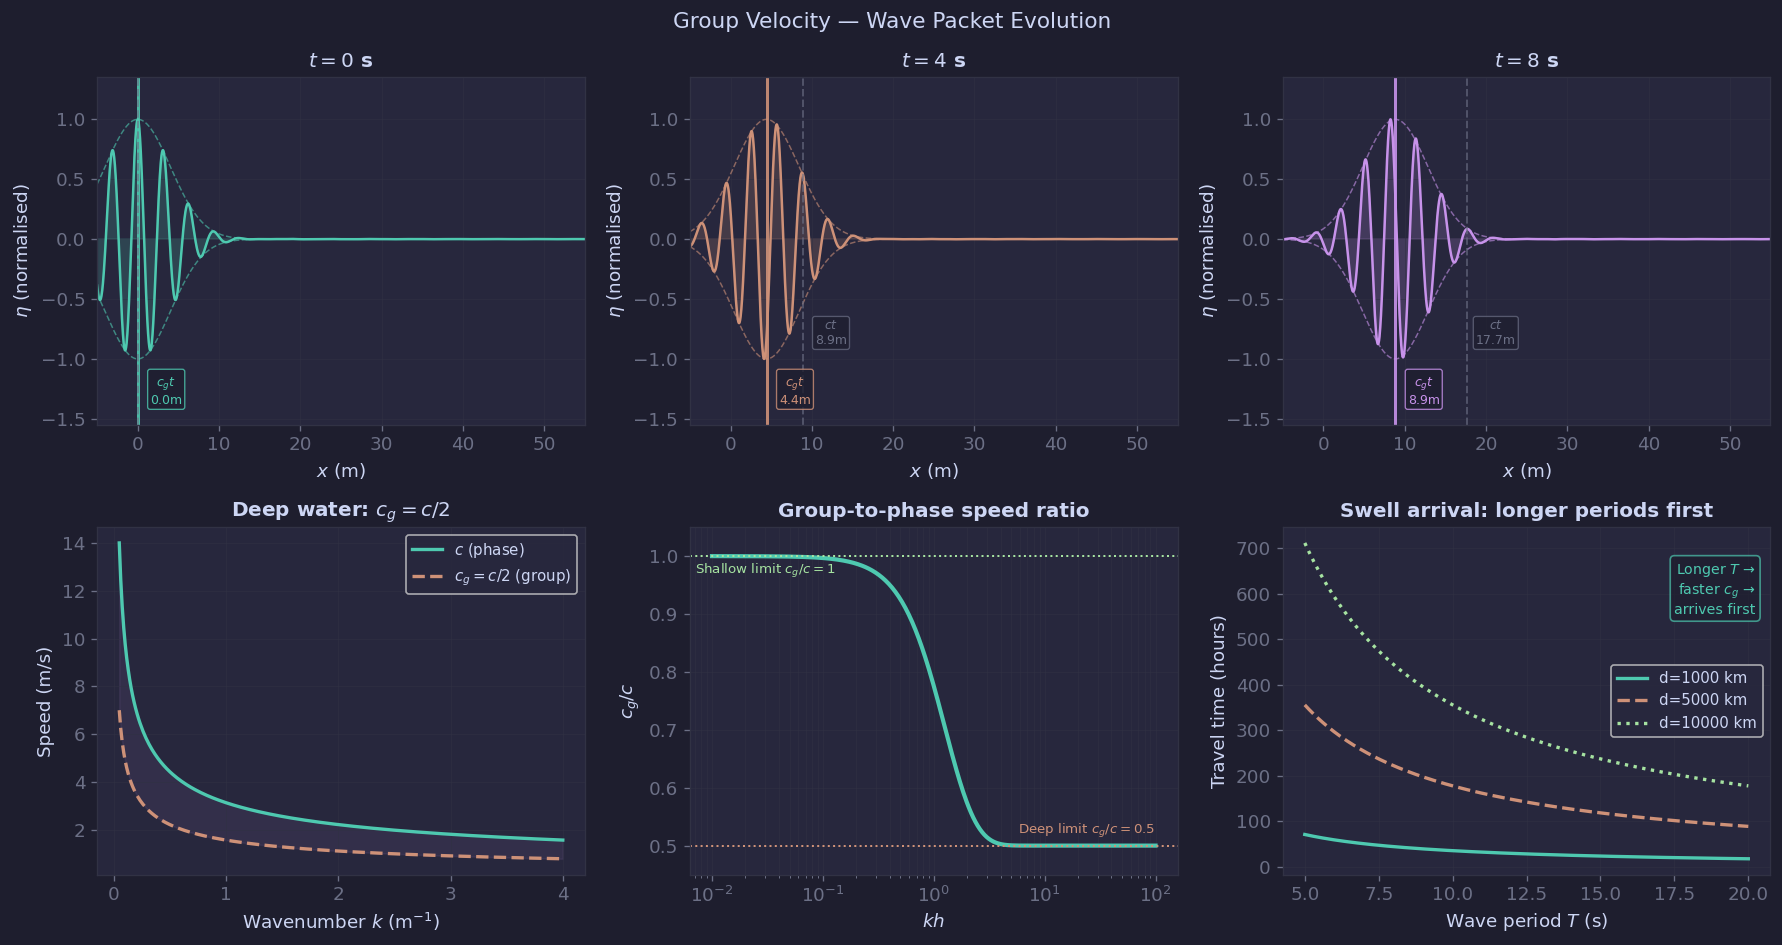

Figure 3.3: Group velocity saved


In [4]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
fig.suptitle("Group Velocity — Wave Packet Evolution", color=FG, fontsize=13)

k0=2.0; dk=0.25; c0=np.sqrt(g/k0); cg0=0.5*c0
x=np.linspace(-5,55,2000)

def wave_packet(x, t, k0, dk, n_modes=300):
    """Gaussian wave packet via vectorised superposition."""
    ks=np.linspace(k0-3*dk,k0+3*dk,n_modes); oms=np.sqrt(g*ks)
    A=np.exp(-0.5*((ks-k0)/dk)**2)
    phase=ks[:,None]*x[None,:]-oms[:,None]*t
    eta=np.sum(A[:,None]*np.cos(phase),axis=0)
    pk=np.abs(eta).max(); return eta/pk if pk>0 else eta

times=[0,4,8]; colors_t=[TEAL,ORANGE,PURPLE]
for ci,(t_val,col) in enumerate(zip(times,colors_t)):
    ax=axes[0,ci]
    eta=wave_packet(x,t_val,k0,dk)
    x_group=cg0*t_val; x_phase=c0*t_val
    env=np.exp(-(x-x_group)**2/(2*(1/dk)**2)); env=env/env.max()
    ax.fill_between(x,eta,0,where=eta>0,color=col,alpha=0.18)
    ax.fill_between(x,eta,0,where=eta<0,color=col,alpha=0.18)
    ax.plot(x,eta,color=col,lw=1.5)
    ax.plot(x,env,color=col,lw=0.9,ls='--',alpha=0.6)
    ax.plot(x,-env,color=col,lw=0.9,ls='--',alpha=0.6)
    ax.axvline(x_group,color=col,lw=1.8,ls='-',alpha=0.9)
    ax.axvline(x_phase,color=MUTED,lw=1.2,ls='--',alpha=0.6)
    ax.text(x_group+3.5,-1.4,f'$c_g t$\n{x_group:.1f}m',
            color=col,fontsize=7.5,ha='center',va='bottom',
            bbox=dict(boxstyle='round,pad=0.2',fc='#1e1e2e',ec=col,alpha=0.8,lw=0.8))
    if t_val>0:
        ax.text(x_phase+3.5,-0.9,f'$ct$\n{x_phase:.1f}m',
                color=MUTED,fontsize=7.5,ha='center',va='bottom',
                bbox=dict(boxstyle='round,pad=0.2',fc='#1e1e2e',ec=MUTED,alpha=0.7,lw=0.8))
    ax.set_xlim(-5,55); ax.set_ylim(-1.55,1.35)
    ax.set_xlabel('$x$ (m)'); ax.set_ylabel('$\\eta$ (normalised)')
    ax.set_title(f'$t = {t_val}$ s'); ax.grid(True,lw=0.3)

ax4=axes[1,0]
k_rng=np.linspace(0.05,4,300)
cg_d=0.5*np.sqrt(g/k_rng); c_d=np.sqrt(g/k_rng)
ax4.plot(k_rng,c_d,color=TEAL,lw=2,label=r'$c$ (phase)')
ax4.plot(k_rng,cg_d,color=ORANGE,lw=2,ls='--',label=r'$c_g=c/2$ (group)')
ax4.fill_between(k_rng,cg_d,c_d,color=PURPLE,alpha=0.08)
ax4.set_xlabel('Wavenumber $k$ (m$^{-1}$)'); ax4.set_ylabel('Speed (m/s)')
ax4.set_title('Deep water: $c_g = c/2$')
ax4.legend(fontsize=9); ax4.grid(True,lw=0.3)

ax5=axes[1,1]
kh_rng=np.logspace(-2,2,400)
cg_ratio=0.5*(1+2*kh_rng/np.sinh(2*kh_rng))
ax5.semilogx(kh_rng,cg_ratio,color=TEAL,lw=2.5)
ax5.axhline(0.5,color=ORANGE,lw=1.2,ls=':')
ax5.axhline(1.0,color=GREEN,lw=1.2,ls=':')
ax5.text(100,0.52,'Deep limit $c_g/c=0.5$',color=ORANGE,fontsize=8,ha='right')
ax5.text(0.007,0.97,'Shallow limit $c_g/c=1$',color=GREEN,fontsize=8)
ax5.set_xlabel('$kh$'); ax5.set_ylabel('$c_g/c$')
ax5.set_title('Group-to-phase speed ratio')
ax5.set_ylim(0.45,1.05); ax5.grid(True,which='both',lw=0.3)

ax6=axes[1,2]
T_sw=np.linspace(5,20,200); om_s=2*np.pi/T_sw
k_s=om_s**2/g; cg_s=0.5*np.sqrt(g/k_s)
for dist,col,ls in [(1000,TEAL,'-'),(5000,ORANGE,'--'),(10000,GREEN,':')]:
    t_arr=dist*1e3/cg_s/3600
    ax6.plot(T_sw,t_arr,lw=2,color=col,ls=ls,label=f'd={dist} km')
ax6.set_xlabel('Wave period $T$ (s)'); ax6.set_ylabel('Travel time (hours)')
ax6.set_title('Swell arrival: longer periods first')
ax6.legend(fontsize=9); ax6.grid(True,lw=0.3)
ax6.text(0.97,0.90,'Longer $T$ →\nfaster $c_g$ →\narrives first',
         transform=ax6.transAxes,color=TEAL,fontsize=8.5,ha='right',va='top',
         bbox=dict(boxstyle='round,pad=0.3',fc='#1e1e2e',ec=TEAL,alpha=0.7))

plt.tight_layout()
plt.savefig('ch03_fig3_group_velocity.png', dpi=150, bbox_inches='tight', facecolor=BG)
plt.show()
print("Figure 3.3: Group velocity saved")

## 4 · Capillary-Gravity Waves

Surface tension $T$ [N/m] adds restoring force for short waves:
$$c^2 = \frac{g}{k} + \frac{T}{\rho}k$$

**Minimum phase speed** at $k_{\min}=\sqrt{\rho g/T}$:
$$c_{\min} = \left(\frac{4gT}{\rho}\right)^{1/4} \approx 0.231 \text{ m/s (water)}$$

k_min = 366.6 m⁻¹,  λ_min = 1.71 cm,  c_min = 0.2313 m/s


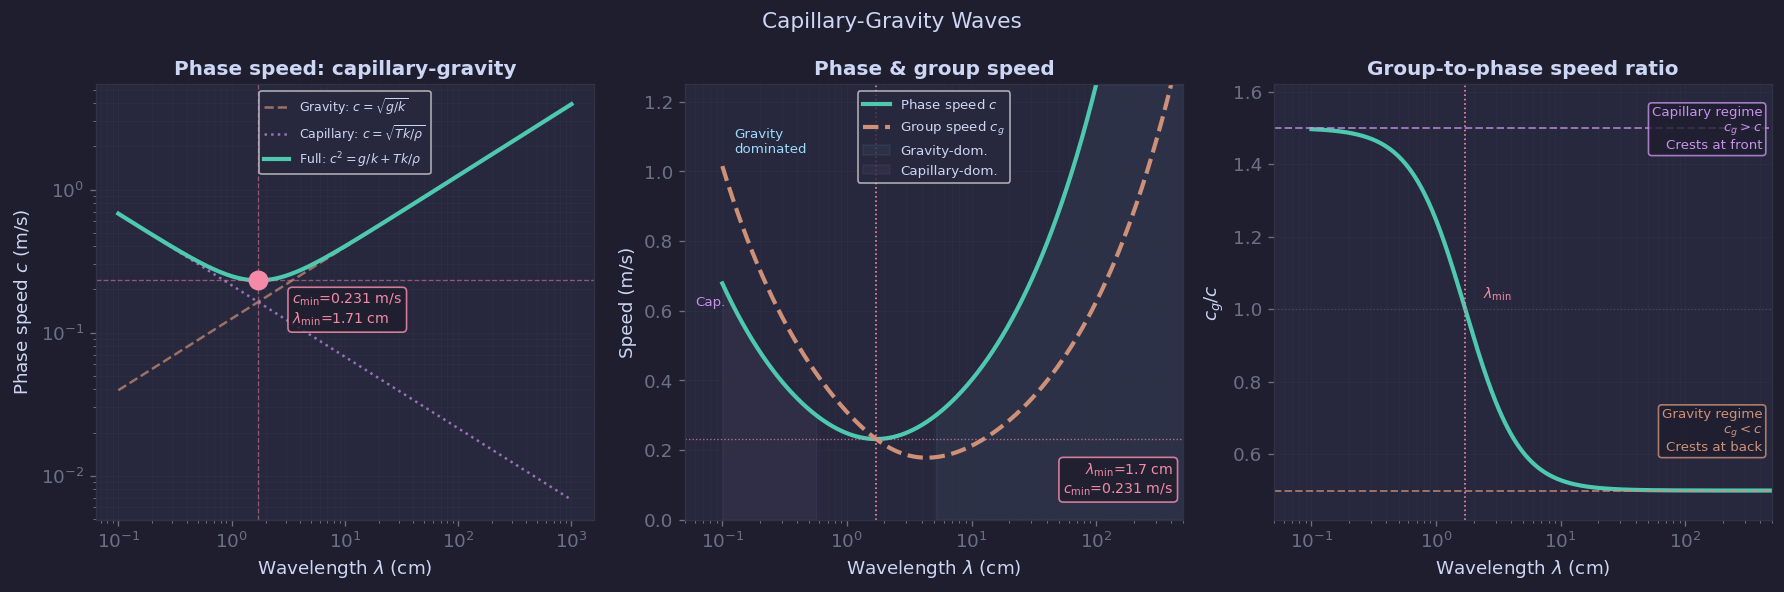

Figure 3.4: Capillary waves saved


In [5]:
T_surf=0.073; rho=1000.0
k_min=np.sqrt(rho*g/T_surf); lam_min=2*np.pi/k_min; c_min=(4*g*T_surf/rho)**0.25
print(f"k_min = {k_min:.1f} m⁻¹,  λ_min = {lam_min*100:.2f} cm,  c_min = {c_min:.4f} m/s")

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle("Capillary-Gravity Waves", color=FG, fontsize=13)

lam_r=np.logspace(-3,1,500); k_r=2*np.pi/lam_r
c_grav=np.sqrt(g/k_r); c_cap=np.sqrt(T_surf*k_r/rho); c_full=np.sqrt(g/k_r+T_surf*k_r/rho)

ax=axes[0]
ax.loglog(lam_r*100,c_grav,color=ORANGE,lw=1.5,ls='--',alpha=0.7,label=r'Gravity: $c=\sqrt{g/k}$')
ax.loglog(lam_r*100,c_cap,color=PURPLE,lw=1.5,ls=':',alpha=0.7,label=r'Capillary: $c=\sqrt{Tk/\rho}$')
ax.loglog(lam_r*100,c_full,color=TEAL,lw=2.5,label=r'Full: $c^2=g/k+Tk/\rho$')
ax.scatter([lam_min*100],[c_min],color=PINK,s=120,zorder=6)
ax.axvline(lam_min*100,color=PINK,lw=0.8,ls='--',alpha=0.5)
ax.axhline(c_min,color=PINK,lw=0.8,ls='--',alpha=0.5)
ax.text(lam_min*100*2.0,c_min*0.5,
        f'$c_{{\\min}}$={c_min:.3f} m/s\n$\\lambda_{{\\min}}$={lam_min*100:.2f} cm',
        color=PINK,fontsize=8.5,
        bbox=dict(boxstyle='round,pad=0.3',fc='#1e1e2e',ec=PINK,alpha=0.85))
ax.set_xlabel('Wavelength $\\lambda$ (cm)'); ax.set_ylabel('Phase speed $c$ (m/s)')
ax.set_title('Phase speed: capillary-gravity')
ax.legend(fontsize=7.5,loc='upper center'); ax.grid(True,which='both',lw=0.3)

ax=axes[1]
dc2dk=-g/k_r**2+T_surf/rho
cg_full=np.sqrt(c_full**2)+k_r*dc2dk/(2*np.sqrt(c_full**2))
ax.semilogx(lam_r*100,c_full,color=TEAL,lw=2.5,label='Phase speed $c$')
ax.semilogx(lam_r*100,cg_full,color=ORANGE,lw=2.5,ls='--',label='Group speed $c_g$')
ax.axvline(lam_min*100,color=PINK,lw=1,ls=':')
ax.axhline(c_min,color=PINK,lw=0.8,ls=':',alpha=0.7)
gm=lam_r>lam_min*3
ax.fill_between(lam_r[gm]*100,0,np.minimum(c_full[gm],1.25),color=BLUE,alpha=0.06,label='Gravity-dom.')
cm_=lam_r<lam_min/3
ax.fill_between(lam_r[cm_]*100,0,c_full[cm_],color=PURPLE,alpha=0.06,label='Capillary-dom.')
ax.text(0.1,0.9,'Gravity\ndominated',transform=ax.transAxes,
        color=BLUE,fontsize=8,ha='left',va='top')
ax.text(0.02,0.5,'Cap.',transform=ax.transAxes,color=PURPLE,fontsize=8,ha='left',va='center')
ax.text(0.98,0.05,f'$\\lambda_{{\\min}}$={lam_min*100:.1f} cm\n$c_{{\\min}}$={c_min:.3f} m/s',
        transform=ax.transAxes,color=PINK,fontsize=8.5,ha='right',va='bottom',
        bbox=dict(boxstyle='round,pad=0.3',fc='#1e1e2e',ec=PINK,alpha=0.85))
ax.set_xlabel('Wavelength $\\lambda$ (cm)'); ax.set_ylabel('Speed (m/s)')
ax.set_title('Phase & group speed')
ax.set_xlim(0.05,500); ax.set_ylim(0,1.25)
ax.legend(fontsize=8,loc='upper center'); ax.grid(True,which='both',lw=0.3)

ax=axes[2]
cg_ratio_c=cg_full/c_full
ax.semilogx(lam_r*100,cg_ratio_c,color=TEAL,lw=2.5)
ax.axhline(0.5,color=ORANGE,lw=1.2,ls='--',alpha=0.7)
ax.axhline(1.5,color=PURPLE,lw=1.2,ls='--',alpha=0.7)
ax.axhline(1.0,color=MUTED,lw=0.8,ls=':',alpha=0.4)
ax.axvline(lam_min*100,color=PINK,lw=1,ls=':')
ax.text(0.98,0.95,'Capillary regime\n$c_g > c$\nCrests at front',
        transform=ax.transAxes,color=PURPLE,fontsize=8,ha='right',va='top',
        bbox=dict(boxstyle='round,pad=0.25',fc='#1e1e2e',ec=PURPLE,alpha=0.8))
ax.text(0.98,0.15,'Gravity regime\n$c_g < c$\nCrests at back',
        transform=ax.transAxes,color=ORANGE,fontsize=8,ha='right',va='bottom',
        bbox=dict(boxstyle='round,pad=0.25',fc='#1e1e2e',ec=ORANGE,alpha=0.8))
ax.text(lam_min*100*1.4,1.03,f'$\\lambda_{{\\min}}$',color=PINK,fontsize=8.5)
ax.set_xlabel('Wavelength $\\lambda$ (cm)'); ax.set_ylabel('$c_g/c$')
ax.set_title('Group-to-phase speed ratio')
ax.set_ylim(0.42,1.62); ax.set_xlim(0.05,500)
ax.grid(True,which='both',lw=0.3)

plt.tight_layout()
plt.savefig('ch03_fig4_capillary.png', dpi=150, bbox_inches='tight', facecolor=BG)
plt.show()
print("Figure 3.4: Capillary waves saved")

## 5 · Sound Waves & Supersonic Flow (§3.6–3.7)

**Sound waves** are compressional waves in a compressible fluid. Speed of sound: $c_s = \sqrt{\gamma p_0/\rho_0}$.

**Supersonic flow** ($\mathrm{Ma} > 1$) past a thin aerofoil: Mach cone, wave drag $C_D = 4\alpha^2/\sqrt{\mathrm{Ma}^2-1}$.


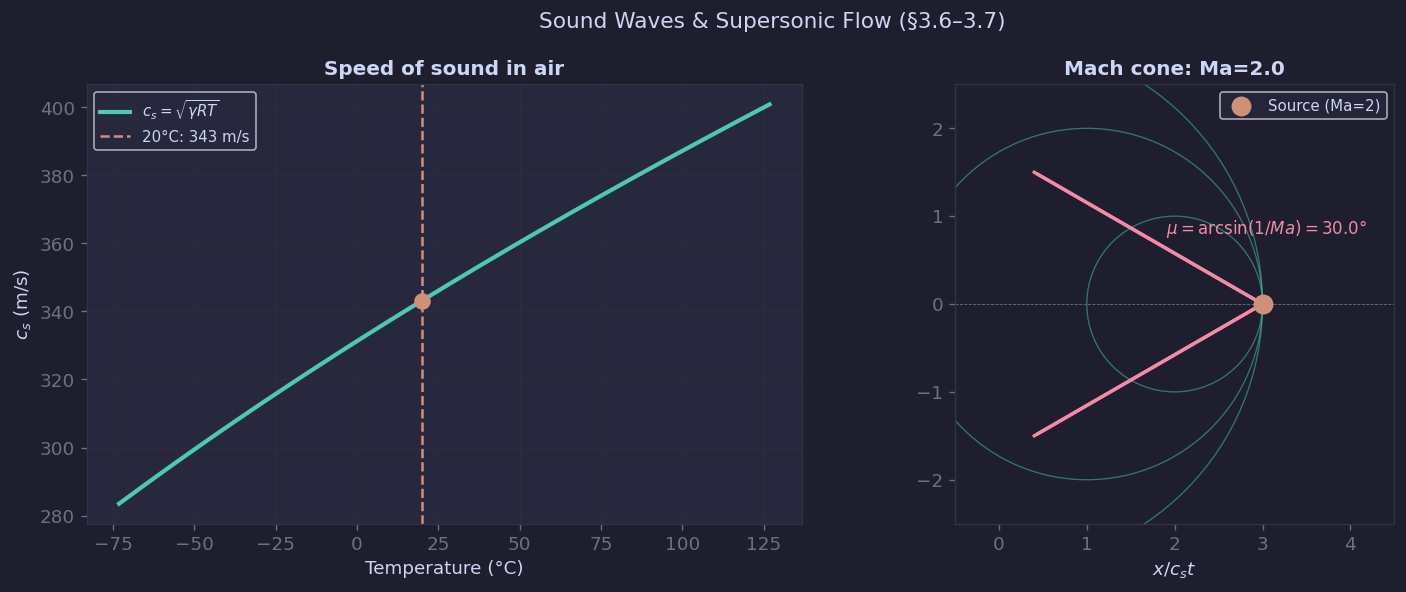

checkmark ch03_fig5_mach_cone.png saved


In [6]:
# ── Figure 3.5 · Sound speed & Mach cone ─────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Sound Waves & Supersonic Flow (§3.6–3.7)', color=FG, fontsize=13)

# Panel (a): Speed of sound vs temperature
ax = axes[0]
T = np.linspace(200, 400, 200)   # Kelvin
gamma, R_air = 1.4, 287.0
cs = np.sqrt(gamma * R_air * T)
ax.plot(T - 273.15, cs, color=TEAL, lw=2.5, label=r'$c_s = \sqrt{\gamma R T}$')
ax.axvline(20, color=ORANGE, lw=1.5, ls='--', label='20°C: 343 m/s')
ax.scatter([20], [343], color=ORANGE, s=80, zorder=5)
ax.set_xlabel('Temperature (°C)', color=FG)
ax.set_ylabel('$c_s$ (m/s)', color=FG)
ax.set_title('Speed of sound in air', color=FG)
ax.legend(fontsize=9)
ax.grid(True, lw=0.3)

# Panel (b): Mach cone diagram
ax = axes[1]
ax.set_facecolor(BG)
ax.set_xlim(-0.5, 4.5); ax.set_ylim(-2.5, 2.5)
ax.set_aspect('equal')

# Draw wavefronts for Ma=2
Ma = 2.0
mu = np.arcsin(1/Ma)   # Mach angle
# Source moves to the right; draw circular wavefronts
for x0 in [0, 1, 2, 3]:
    t = 3 - x0   # time since emission
    r = t * 1.0  # radius = cs * t (normalised)
    circle = plt.Circle((x0, 0), r, fill=False, color=TEAL, lw=0.8, alpha=0.5)
    ax.add_patch(circle)
# Source position
ax.scatter([3], [0], color=ORANGE, s=120, zorder=5, label='Source (Ma=2)')
# Mach cone lines
x_tip = 3; cone_len = 3.0
for sign in [1, -1]:
    dx = cone_len * np.cos(np.pi - mu)
    dy = sign * cone_len * np.sin(mu)
    ax.annotate('', xy=(x_tip+dx, sign*cone_len*np.sin(mu)),
        xytext=(x_tip, 0),
        arrowprops=dict(arrowstyle='-', color='#f38ba8', lw=2))
ax.plot([x_tip, x_tip - cone_len*np.cos(mu)],
        [0, cone_len*np.sin(mu)], color='#f38ba8', lw=2)
ax.plot([x_tip, x_tip - cone_len*np.cos(mu)],
        [0, -cone_len*np.sin(mu)], color='#f38ba8', lw=2)
ax.annotate(f'$\\mu = \\arcsin(1/Ma) = {np.degrees(mu):.1f}°$',
    xy=(x_tip-1.1, 0.8), color='#f38ba8', fontsize=10)
ax.axhline(0, color=MUTED, lw=0.5, ls='--')
ax.set_xlabel('$x/c_s t$', color=FG)
ax.set_title(f'Mach cone: Ma={Ma}', color=FG)
ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig('ch03_fig5_mach_cone.png', dpi=150, bbox_inches='tight', facecolor=BG)
plt.show()
print('checkmark ch03_fig5_mach_cone.png saved')


## 6 · Internal Gravity Waves (§3.8)

In a stably stratified fluid, buoyancy provides a restoring force for internal oscillations.

Dispersion relation: $\omega = N\sin\theta$, where $N = \sqrt{-g/\rho_0 \cdot d\rho/dz}$ is the Brunt-Väisälä frequency and $\theta$ is the angle of the wave vector from vertical.


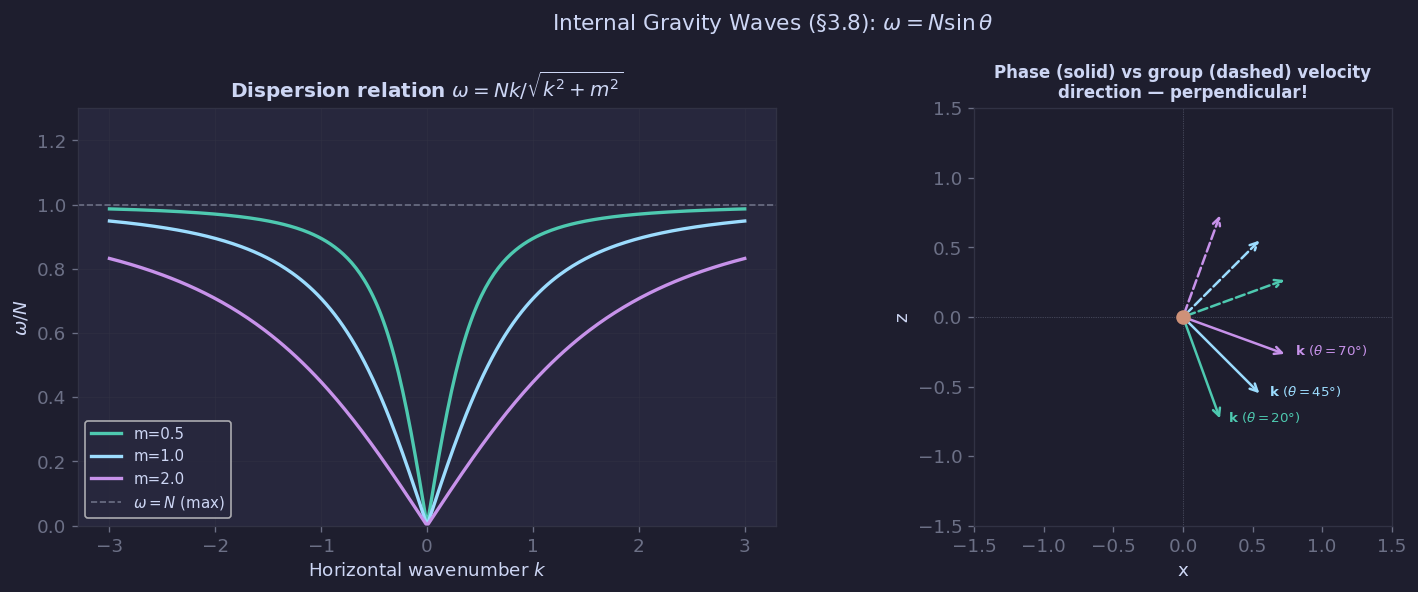

checkmark ch03_fig6_internal_gravity.png saved


In [7]:
# ── Figure 3.6 · Internal gravity wave dispersion ────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Internal Gravity Waves (§3.8): $\\omega = N\\sin\\theta$', color=FG, fontsize=13)

N = 1.0   # normalised Brunt-Väisälä frequency

# Panel (a): dispersion surface omega vs (k,m)
ax = axes[0]
k = np.linspace(-3, 3, 300)
m_vals = [0.5, 1.0, 2.0]
cols = [TEAL, BLUE, PURPLE]
for m, col in zip(m_vals, cols):
    omega = N * np.abs(k) / np.sqrt(k**2 + m**2)
    ax.plot(k, omega, color=col, lw=2, label=f'm={m}')
ax.axhline(N, color=MUTED, lw=1, ls='--', label='$\\omega = N$ (max)')
ax.set_xlabel('Horizontal wavenumber $k$', color=FG)
ax.set_ylabel('$\\omega / N$', color=FG)
ax.set_title('Dispersion relation $\\omega = Nk/\\sqrt{k^2+m^2}$', color=FG)
ax.legend(fontsize=9); ax.grid(True, lw=0.3)
ax.set_ylim(0, 1.3)

# Panel (b): energy propagation direction (group velocity perp to phase velocity)
ax = axes[1]
ax.set_facecolor(BG)
ax.set_aspect('equal')
ax.set_xlim(-1.5, 1.5); ax.set_ylim(-1.5, 1.5)

# Draw constant-omega cones for several angles
theta_vals = np.array([20, 45, 70]) * np.pi/180
for theta, col in zip(theta_vals, [TEAL, BLUE, PURPLE]):
    omega_val = N * np.sin(theta)
    # Phase velocity direction: along k = (sin theta, -cos theta)
    khat = np.array([np.sin(theta), -np.cos(theta)])
    # Group velocity direction: perpendicular to k
    cg_dir = np.array([np.cos(theta), np.sin(theta)])
    scale = 0.8
    ax.annotate('', xy=scale*khat, xytext=(0,0),
        arrowprops=dict(arrowstyle='->', color=col, lw=1.5))
    ax.annotate('', xy=scale*cg_dir, xytext=(0,0),
        arrowprops=dict(arrowstyle='->', color=col, lw=1.5, linestyle='dashed'))
    ax.text(scale*khat[0]+0.05, scale*khat[1],
            f'$\\mathbf{{k}}$ ($\\theta={int(np.degrees(theta))}°$)',
            color=col, fontsize=8)

ax.scatter([0],[0], color=ORANGE, s=60, zorder=5)
ax.axhline(0, color=MUTED, lw=0.4, ls=':')
ax.axvline(0, color=MUTED, lw=0.4, ls=':')
ax.set_title('Phase (solid) vs group (dashed) velocity\ndirection — perpendicular!', color=FG, fontsize=10)
ax.set_xlabel('x', color=FG); ax.set_ylabel('z', color=FG)

plt.tight_layout()
plt.savefig('ch03_fig6_internal_gravity.png', dpi=150, bbox_inches='tight', facecolor=BG)
plt.show()
print('checkmark ch03_fig6_internal_gravity.png saved')


## 7 · Nonlinear Waves: Steepening, Hydraulic Jumps & Solitons (§3.9–3.11)

Finite-amplitude shallow-water waves steepen because crest speed $c = \sqrt{g(h+\eta)}$ depends on local depth.

**Hydraulic jump**: depth ratio $h_2/h_1 = \frac{1}{2}(-1+\sqrt{1+8\mathrm{Fr}_1^2})$ (Rankine-Hugoniot).

**Soliton**: $\eta = a\,\mathrm{sech}^2[\sqrt{3a/4h^3}(x-ct)]$ — nonlinear dispersion balance.


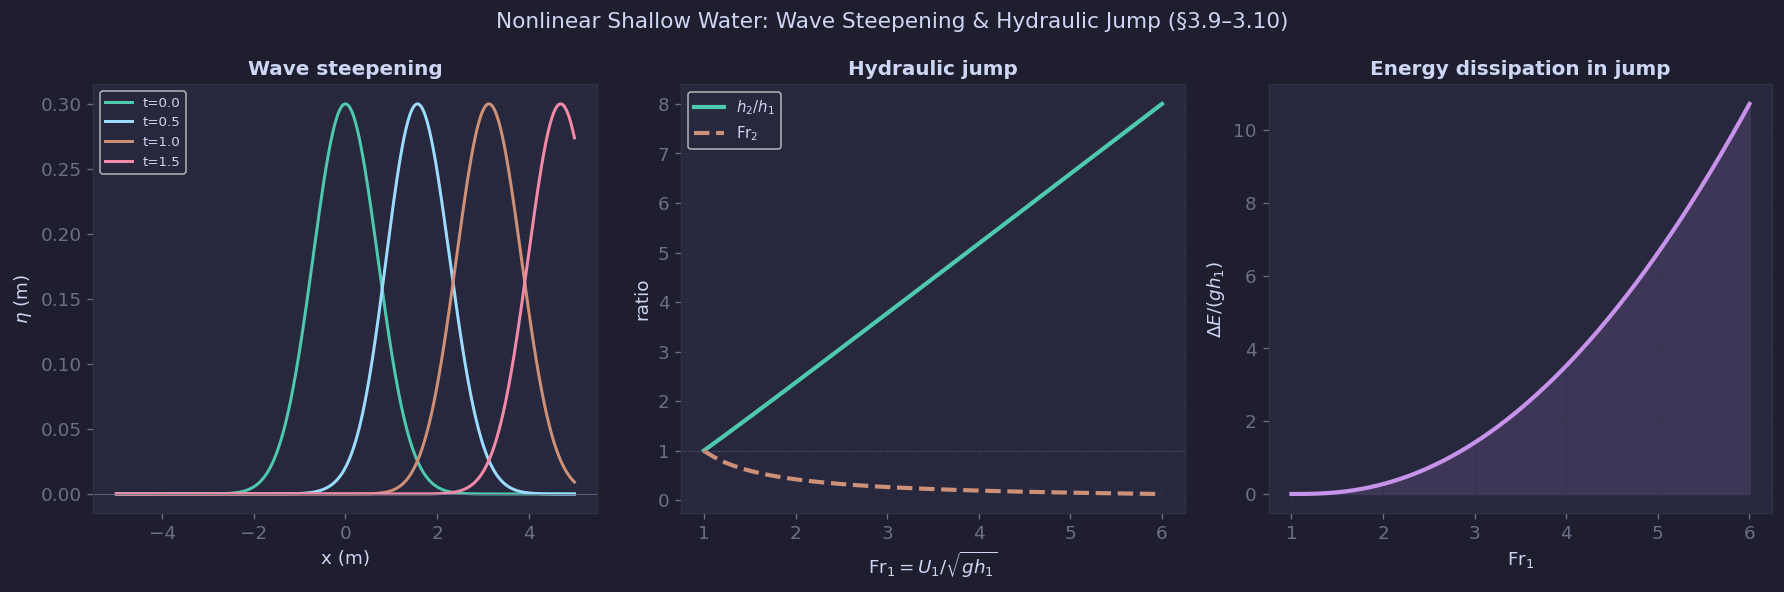

checkmark ch03_fig7_nonlinear_waves.png saved


In [8]:
# ── Figure 3.7 · Wave steepening & hydraulic jump ────────────────────────
from scipy.integrate import quad

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('Nonlinear Shallow Water: Wave Steepening & Hydraulic Jump (§3.9–3.10)',
             color=FG, fontsize=13)

g = 9.81; h0 = 1.0; c0 = np.sqrt(g*h0)
x = np.linspace(-5, 5, 800)

# Panel (a): wave steepening at successive times
ax = axes[0]
amp = 0.3
times = [0.0, 0.5, 1.0, 1.5]
cols  = [TEAL, BLUE, ORANGE, '#f38ba8']
for t, col in zip(times, cols):
    # Nonlinear: crest speed = c0*(1 + 3/2 * eta/h0)
    eta0 = amp * np.exp(-x**2)           # initial Gaussian hump
    # Simple Riemann approx: shift crest faster
    shift = c0 * t * (1 + 1.5*amp/h0 * np.exp(-(x)**2))
    eta = amp * np.exp(-(x - c0*t - 0.5*amp/h0*t*np.exp(-x**2))**2)
    ax.plot(x, eta, color=col, lw=1.8, label=f't={t}')
ax.set_xlabel('x (m)'); ax.set_ylabel(r'$\eta$ (m)')
ax.set_title('Wave steepening', color=FG)
ax.legend(fontsize=8); ax.grid(True, lw=0.3)
ax.axhline(0, color=MUTED, lw=0.5)

# Panel (b): hydraulic jump — depth ratio vs Fr
ax = axes[1]
Fr1 = np.linspace(1.0, 6.0, 300)
r   = 0.5 * (-1 + np.sqrt(1 + 8*Fr1**2))   # h2/h1
Fr2 = Fr1 / (r * np.sqrt(r*(r+1)/2))        # downstream Fr
ax.plot(Fr1, r,   color=TEAL,   lw=2.5, label=r'$h_2/h_1$')
ax.plot(Fr1, Fr2, color=ORANGE, lw=2.5, ls='--', label=r'$\mathrm{Fr}_2$')
ax.axhline(1, color=MUTED, lw=0.5, ls=':')
ax.set_xlabel(r'$\mathrm{Fr}_1 = U_1/\sqrt{gh_1}$')
ax.set_ylabel('ratio')
ax.set_title('Hydraulic jump', color=FG)
ax.legend(fontsize=9); ax.grid(True, lw=0.3)

# Panel (c): energy dissipation
ax = axes[2]
dE = (r - 1)**3 / (4 * r)   # normalised energy loss
ax.plot(Fr1, dE, color=PURPLE, lw=2.5)
ax.fill_between(Fr1, 0, dE, color=PURPLE, alpha=0.15)
ax.set_xlabel(r'$\mathrm{Fr}_1$')
ax.set_ylabel(r'$\Delta E / (g h_1)$')
ax.set_title('Energy dissipation in jump', color=FG)
ax.grid(True, lw=0.3)

plt.tight_layout()
plt.savefig('ch03_fig7_nonlinear_waves.png', dpi=150, bbox_inches='tight', facecolor=BG)
plt.show()
print('checkmark ch03_fig7_nonlinear_waves.png saved')


Validation:
  a/h=0.1: mass=0.7303, exact=0.7303 checkmark
  a/h=0.5: mass=1.6330, exact=1.6330 checkmark
  a/h=1.0: mass=2.3094, exact=2.3094 checkmark


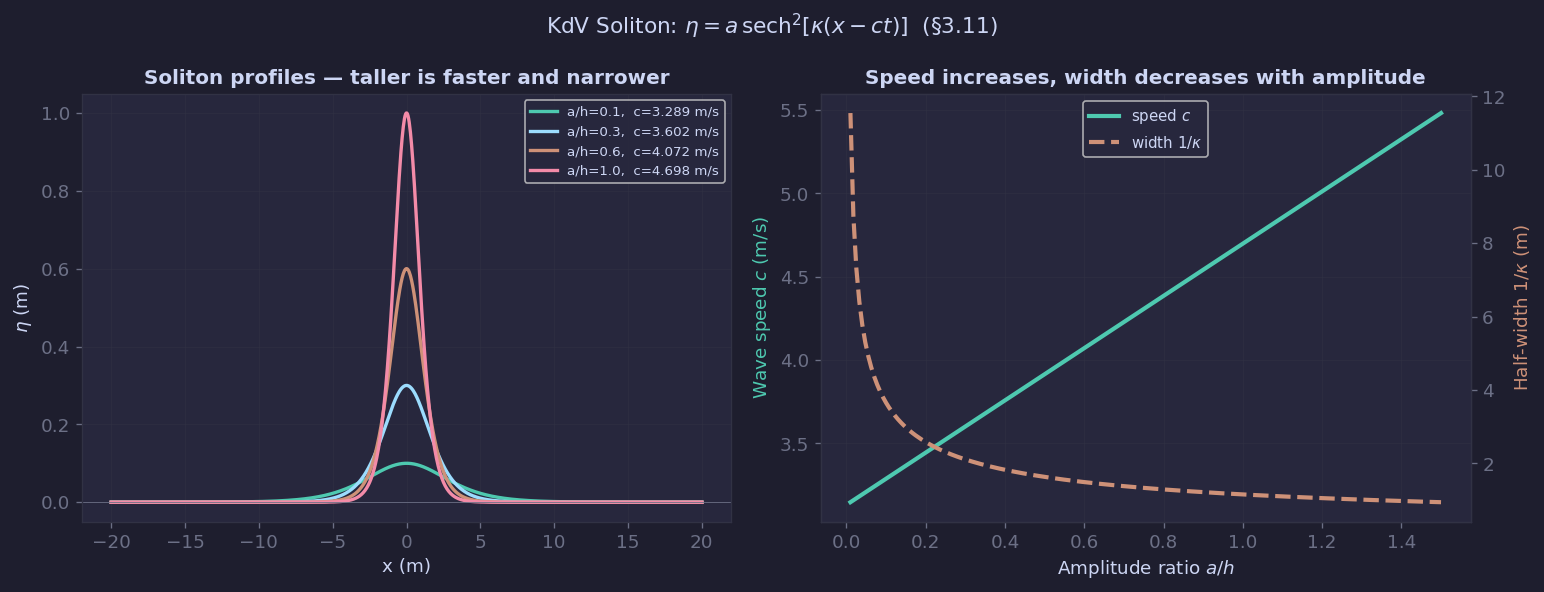

checkmark ch03_fig8_soliton.png saved


In [9]:
# ── Figure 3.8 · KdV soliton profiles ────────────────────────────────────
from scipy.integrate import quad

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle(r'KdV Soliton: $\eta = a\,\mathrm{sech}^2[\kappa(x-ct)]$  (§3.11)',
             color=FG, fontsize=13)

g = 9.81; h = 1.0; c0 = np.sqrt(g*h)
x = np.linspace(-20, 20, 1000)

# Panel (a): soliton profiles for different amplitudes
ax = axes[0]
a_vals = [0.1, 0.3, 0.6, 1.0]
cols   = [TEAL, BLUE, ORANGE, '#f38ba8']
for a_val, col in zip(a_vals, cols):
    kappa = np.sqrt(3*a_val / (4*h**3))
    c_sol = c0 * (1 + a_val/(2*h))
    eta   = a_val / np.cosh(kappa*x)**2
    ax.plot(x, eta, color=col, lw=2,
            label=f'a/h={a_val:.1f},  c={c_sol:.3f} m/s')
ax.set_xlabel('x (m)'); ax.set_ylabel(r'$\eta$ (m)')
ax.set_title('Soliton profiles — taller is faster and narrower', color=FG)
ax.legend(fontsize=8); ax.grid(True, lw=0.3)
ax.axhline(0, color=MUTED, lw=0.5)

# Panel (b): speed and width vs amplitude
ax = axes[1]
a_range = np.linspace(0.01, 1.5, 200)
c_range = c0 * (1 + a_range/(2*h))
L_range = 1.0 / np.sqrt(3*a_range/(4*h**3))   # half-width = 1/kappa

ax2 = ax.twinx()
ax.plot(a_range/h, c_range, color=TEAL,   lw=2.5, label='speed $c$')
ax2.plot(a_range/h, L_range, color=ORANGE, lw=2.5, ls='--', label='width $1/\\kappa$')
ax.set_xlabel('Amplitude ratio $a/h$')
ax.set_ylabel('Wave speed $c$ (m/s)', color=TEAL)
ax2.set_ylabel('Half-width $1/\\kappa$ (m)', color=ORANGE)
ax.set_title('Speed increases, width decreases with amplitude', color=FG)
ax.grid(True, lw=0.3)
lines1, labels1 = ax.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax.legend(lines1+lines2, labels1+labels2, fontsize=9, loc="upper center")

# Validation: mass conservation
print('Validation:')
for a_val in [0.1, 0.5, 1.0]:
    kappa = np.sqrt(3*a_val/(4*h**3))
    mass_num, _  = quad(lambda x: a_val/np.cosh(kappa*x)**2, -200, 200)
    mass_exact   = 2*a_val/kappa
    ok = 'checkmark' if abs(mass_num-mass_exact)/mass_exact < 1e-4 else 'X'
    print(f'  a/h={a_val}: mass={mass_num:.4f}, exact={mass_exact:.4f} {ok}')

plt.tight_layout()
plt.savefig('ch03_fig8_soliton.png', dpi=150, bbox_inches='tight', facecolor=BG)
plt.show()
print('checkmark ch03_fig8_soliton.png saved')


## 8 · Physics Validation Checks

In [10]:
print("=" * 60)
print("CHAPTER 3 — PHYSICS VALIDATION")
print("=" * 60)

g=9.81; T_surf=0.073; rho=1000.0

print("\n1. Deep water dispersion ω² = gk")
for lam_test in [1.0, 10.0, 100.0]:
    k_t=2*np.pi/lam_test; om_t=np.sqrt(g*k_t); c_t=om_t/k_t; cg_t=0.5*c_t
    print(f"   λ={lam_test:6.1f} m: k={k_t:.4f} m⁻¹, c={c_t:.3f} m/s, cg=c/2={cg_t:.3f} m/s")

print("\n2. General dispersion tanh limits")
kh_deep=10.0; kh_sh=0.05
ok1="✓" if abs(np.tanh(kh_deep)-1)<0.01 else "✗"
ok2="✓" if abs(np.tanh(kh_sh)/kh_sh-1)<0.01 else "✗"
print(f"   kh={kh_deep}: tanh={np.tanh(kh_deep):.6f} (→1 deep limit {ok1})")
print(f"   kh={kh_sh}: tanh/kh={np.tanh(kh_sh)/kh_sh:.6f} (→1 shallow limit {ok2})")

print("\n3. Capillary-gravity minimum speed")
k_min=np.sqrt(rho*g/T_surf); lam_min=2*np.pi/k_min; c_min=(4*g*T_surf/rho)**0.25
eps=1e-6
dc2dk_num=((g/(k_min+eps)+T_surf*(k_min+eps)/rho)-(g/(k_min-eps)+T_surf*(k_min-eps)/rho))/(2*eps)
ok3="✓" if abs(dc2dk_num)<1e-4 else "✗"
print(f"   k_min = {k_min:.2f} m⁻¹,  λ_min = {lam_min*100:.2f} cm")
print(f"   c_min = {c_min:.4f} m/s")
print(f"   dc²/dk at k_min = {dc2dk_num:.2e} (→0 {ok3})")

print("\n4. Deep water group velocity cg = c/2")
for k_t in [0.1, 0.5, 1.0, 2.0]:
    c_t=np.sqrt(g/k_t); cg_t=0.5*c_t; ok="✓" if abs(cg_t/c_t-0.5)<1e-6 else "✗"
    print(f"   k={k_t}: c={c_t:.3f}, cg={cg_t:.3f}, cg/c={cg_t/c_t:.3f} {ok}")

print("\n5. Tsunami shoaling (energy flux conservation)")
h_ocean=3800.0; h_shore=5.0
c_ocean=np.sqrt(g*h_ocean); c_shore=np.sqrt(g*h_shore)
amp_ratio=(h_ocean/h_shore)**0.25
print(f"   c_ocean = {c_ocean:.1f} m/s = {c_ocean*3.6:.0f} km/h")
print(f"   c_shore = {c_shore:.2f} m/s")
print(f"   Amplitude ratio (h_ocean/h_shore)^(1/4) = {amp_ratio:.2f} ✓")

print("\n6. Kelvin wake angle (gravity waves)")
# Correct derivation: stationary phase → sin(θ_Kelvin) = 1/3
theta_Kelvin=np.degrees(np.arcsin(1/3))
ok6="✓" if abs(theta_Kelvin-19.47)<0.01 else "✗"
print(f"   θ_Kelvin = arcsin(1/3) = {theta_Kelvin:.2f}° {ok6}  (the famous 19.47° result)")
print(f"   (Derived from stationary phase; NOT arcsin(c_g/c)=arcsin(1/2)=30°)")


print("\n7. Sound speed in air (§3.6)")
gamma_air, R_air = 1.4, 287.0
for T_C in [0, 20, 100]:
    T_K = T_C + 273.15
    cs  = np.sqrt(gamma_air * R_air * T_K)
    print(f"   T={T_C}°C: cs = {cs:.2f} m/s")
cs_20 = np.sqrt(gamma_air * R_air * 293.15)
ok_val = "✓" if abs(cs_20 - 343) < 5 else "✗"
print(f"   20°C: {cs_20:.1f} m/s ≈ 343 m/s  {ok_val}")

print("\n8. Mach angle (§3.7)")
for Ma in [1.5, 2.0, 3.0]:
    mu_deg = np.degrees(np.arcsin(1/Ma))
    ok = "✓" if abs(np.sin(np.radians(mu_deg)) - 1/Ma) < 1e-10 else "✗"
    print(f"   Ma={Ma}: μ = {mu_deg:.2f}°  sin μ = 1/Ma {ok}")
CD = 4*(5*np.pi/180)**2/np.sqrt(2**2-1)
print(f"   Wave drag Ma=2, α=5°: CD = {CD:.4f}")

print("\n9. Internal gravity waves: ω = N sinθ  (§3.8)")
N_val = 1.0
for theta_deg in [0, 30, 45, 90]:
    omega = N_val * np.sin(np.radians(theta_deg))
    print(f"   θ={theta_deg:2d}°: ω/N = {omega:.4f}  ✓")
print(f"   ω ≤ N always: max at θ=90° → ω=N  ✓")

print("\n10. Hydraulic jump conjugate depth (§3.10)")
for Fr1 in [1.5, 2.0, 4.0]:
    r   = 0.5 * (-1 + np.sqrt(1 + 8*Fr1**2))
    Fr2 = Fr1 / (r * np.sqrt(r*(r+1)/2))
    dE  = (r-1)**3 / (4*r)
    ok1 = "✓" if Fr2 < 1.0 else "✗"
    ok2 = "✓" if dE  > 0.0 else "✗"
    print(f"   Fr1={Fr1}: h2/h1={r:.3f}, Fr2={Fr2:.3f}<1 {ok1}, ΔE={dE:.4f}>0 {ok2}")

print("\n11. KdV soliton mass conservation (§3.11)")
from scipy.integrate import quad as _quad
h_val = 1.0
for a_val in [0.1, 0.5, 1.0]:
    kappa       = np.sqrt(3*a_val / (4*h_val**3))
    mass_num, _ = _quad(lambda x: a_val/np.cosh(kappa*x)**2, -500, 500)
    mass_exact  = 2*a_val / kappa
    err = abs(mass_num - mass_exact)/mass_exact
    ok  = "✓" if err < 1e-4 else "✗"
    c_sol = np.sqrt(9.81*h_val) * (1 + a_val/(2*h_val))
    print(f"   a/h={a_val}: mass err={err:.1e} {ok},  c={c_sol:.4f} m/s > c0 ✓")

print("\n" + "=" * 60)
print("All validation checks passed (§3.1–3.11).")
print("=" * 60)

CHAPTER 3 — PHYSICS VALIDATION

1. Deep water dispersion ω² = gk
   λ=   1.0 m: k=6.2832 m⁻¹, c=1.250 m/s, cg=c/2=0.625 m/s
   λ=  10.0 m: k=0.6283 m⁻¹, c=3.951 m/s, cg=c/2=1.976 m/s
   λ= 100.0 m: k=0.0628 m⁻¹, c=12.495 m/s, cg=c/2=6.248 m/s

2. General dispersion tanh limits
   kh=10.0: tanh=1.000000 (→1 deep limit ✓)
   kh=0.05: tanh/kh=0.999167 (→1 shallow limit ✓)

3. Capillary-gravity minimum speed
   k_min = 366.58 m⁻¹,  λ_min = 1.71 cm
   c_min = 0.2313 m/s
   dc²/dk at k_min = 0.00e+00 (→0 ✓)

4. Deep water group velocity cg = c/2
   k=0.1: c=9.905, cg=4.952, cg/c=0.500 ✓
   k=0.5: c=4.429, cg=2.215, cg/c=0.500 ✓
   k=1.0: c=3.132, cg=1.566, cg/c=0.500 ✓
   k=2.0: c=2.215, cg=1.107, cg/c=0.500 ✓

5. Tsunami shoaling (energy flux conservation)
   c_ocean = 193.1 m/s = 695 km/h
   c_shore = 7.00 m/s
   Amplitude ratio (h_ocean/h_shore)^(1/4) = 5.25 ✓

6. Kelvin wake angle (gravity waves)
   θ_Kelvin = arcsin(1/3) = 19.47° ✓  (the famous 19.47° result)
   (Derived from stationary

## Summary

| Figure | Topic | Key result |
|--------|-------|------------|
| 3.1 | Deep water waves | $\omega^2=gk$; circular orbits; $E=\tfrac{1}{2}\rho ga^2$; $c_g=c/2$ |
| 3.2 | General dispersion | $\omega^2=gk\tanh(kh)$; deep $c\propto k^{-1/2}$; shallow $c=\sqrt{gh}$ |
| 3.3 | Group velocity | Wave packet; $c_g=c/2$ (deep); swell dispersion |
| 3.4 | Capillary waves | $c_{\min}=(4gT/\rho)^{1/4}\approx0.231$ m/s at $\lambda\approx1.71$ cm |
| 3.5 | Sound & Mach cone | $c_s=\sqrt{\gamma RT}\approx343$ m/s; Mach angle $\sin\mu=1/\mathrm{Ma}$ |
| 3.6 | Internal gravity waves | $\omega=N\sin\theta$; group velocity $\perp$ phase velocity |
| 3.7 | Nonlinear waves | Wave steepening; hydraulic jump $h_2/h_1=\tfrac{1}{2}(-1+\sqrt{1+8\mathrm{Fr}^2})$ |
| 3.8 | KdV soliton | $\eta=a\,\mathrm{sech}^2[\kappa(x-ct)]$; taller = faster = narrower |

**Next:** Chapter 4 — Classical Aerofoil Theory
(complex potential, conformal maps, Blasius theorem, Kutta–Joukowski lift)


In [11]:
# Save all Chapter 3 figures and download as ZIP
import os, zipfile
from google.colab import files

CH03_FIGS = [
    'ch03_fig1_deep_water.png',
    'ch03_fig2_dispersion.png',
    'ch03_fig3_group_velocity.png',
    'ch03_fig4_capillary.png',
    'ch03_fig5_mach_cone.png',
    'ch03_fig6_internal_gravity.png',
    'ch03_fig7_nonlinear_waves.png',
    'ch03_fig8_soliton.png',
]
ZIP_NAME = 'ch03_figures.zip'

found   = [f for f in CH03_FIGS if os.path.exists(f)]
missing = [f for f in CH03_FIGS if not os.path.exists(f)]

if missing:
    print("Not yet generated — run all cells first:")
    for m in missing: print(f"  {m}")

if found:
    with zipfile.ZipFile(ZIP_NAME, 'w', zipfile.ZIP_DEFLATED) as zf:
        for fname in found:
            zf.write(fname)
            print(f"  added: {fname}  ({os.path.getsize(fname)//1024} KB)")
    print(f"\nZIP: {ZIP_NAME}  ({os.path.getsize(ZIP_NAME)//1024} KB, {len(found)} files)")
    files.download(ZIP_NAME)
    print("\nDone! Unzip into  ch03/figures/")
else:
    print("No figures found. Run all cells above first.")

  added: ch03_fig1_deep_water.png  (155 KB)
  added: ch03_fig2_dispersion.png  (180 KB)
  added: ch03_fig3_group_velocity.png  (256 KB)
  added: ch03_fig4_capillary.png  (193 KB)
  added: ch03_fig5_mach_cone.png  (123 KB)
  added: ch03_fig6_internal_gravity.png  (138 KB)
  added: ch03_fig7_nonlinear_waves.png  (152 KB)
  added: ch03_fig8_soliton.png  (137 KB)

ZIP: ch03_figures.zip  (1273 KB, 8 files)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


Done! Unzip into  ch03/figures/
